In [1]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import torch
import torch.distributions as dist

import numpy as np
import ili
from ili.dataloaders import NumpyLoader
from ili.inference import InferenceRunner
from ili.validation.metrics import PosteriorCoverage, PlotSinglePosterior

from chainconsumer import Chain, ChainConsumer, make_sample, Truth
import pandas as pd

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
import cloudpickle as pickle

# print('setting float as default')
# torch.set_default_dtype(torch.float32)


#device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = 'cpu'
print('Device:', device)


def save_obj(obj, name ):
    with open(name + '.pkl', 'wb') as f:
        pickle.dump(obj, f)

def load_obj(name):
    with open(name, 'rb') as f:
        return pickle.load(f)

low=[0.15, 0.5, -1.78]; 
high=[0.52, 1.0, -0.3333]

def mask_prior_and_summaries(theta, summs, low=torch.tensor(low), high=torch.tensor(high)):
    condition = (~torch.any(theta.lt(low), keepdim=True, dim=-1)) & (~torch.any(theta.gt(high), keepdim=True, dim=-1))
    mask = condition.squeeze()
    return theta.float()[mask], summs.float()[mask], mask


def ret_scaled_param(data,param):
    s = 0.6
    if param == 'AIA':
        hi = 3
        lo = -3

    if param == "s8":
        hi = 1.32
        lo = 0.4

    if param == 'om':
        hi = 0.5
        lo = 0.13

    if param == "h":
        hi = 0.6
        lo = 0.8

    if param == 'w':
        hi = -0.33
        lo = -1.8
    if param == "ns":
        hi = 0.99
        lo = 0.94
    if param == 'ob':
        hi = 0.061
        lo = 0.037

    return (data[param] -lo)*s/(hi - lo) + (1 - s)*0.5


# data["s8"]*tf.math.sqrt(data["om"]/0.3)-0.25

def scale_params(theta):
    hi = np.array([0.5, 1.0, -0.33])
    lo = np.array([0.13, 0.0, -1.8])

    theta_ = theta.copy()
    s = 0.6
    
    theta_[:, 0] = (theta[:, 0] - lo[0])*s / (hi[0] - lo[0]) + (1 - s)*0.5
    theta_[:, 1] -= 0.25
    theta_[:, 2] =  (theta[:, 2] - lo[2])*s / (hi[2] - lo[2]) + (1 - s)*0.5
    
    return theta_

def inv_scale_params(theta):

    hi = np.array([0.5, 1.0, -0.33])
    lo = np.array([0.13, 0.0, -1.8])

    theta_ = theta.copy()
    s = 0.6

    theta_[:, 0] = ((theta[:, 0] - (1 - s)*0.5) * (hi[0] - lo[0]) / s) + lo[0]
    theta_[:, 1] += 0.25
    theta_[:, 2] =  ((theta[:, 2] - (1 - s)*0.5) * (hi[2] - lo[2]) / s) + lo[2]
    
    return theta_

    

/Users/lucas/venvs/ltu-ili/lib/python3.10/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Device: cpu


In [2]:
# %cd /Users/lucas/repositories/des-hybrid/density_estimation/local_testing/

/Users/lucas/repositories/des-hybrid/density_estimation/local_testing


/Users/lucas/venvs/ltu-ili/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
def get_S8(theta):
    return np.array([theta[:, 0], theta[:, 1]*np.sqrt(theta[:, 0]/0.3), theta[:, 2]]).T

def get_sigma8(theta):
    return np.array([theta[:, 0], theta[:, 1]/np.sqrt(theta[:, 0]/0.3), theta[:, 2]]).T

In [3]:
foo = scale_params(np.array([[0.27, 0.9, -1.1]]))

print(foo, inv_scale_params(foo))

[[0.42702703 0.65       0.48571429]] [[ 0.27  0.9  -1.1 ]]


In [49]:
# load the regression done on cluster
from sklearn.preprocessing import MinMaxScaler,StandardScaler

# def scale_summs(inputs, min_max=None):
#     if mean_std is not None:
#         min_,max_ = min_max
#     else:
#         min_ = inputs.min(0).values
#         max_ = inputs.max(0).values
#     return (inputs - min_) / (max_ - min_)#inputs.std(0)


def scale_summs(inputs, mean_std=None):
    if mean_std is not None:
        mean,std = mean_std
    else:
        mean = inputs.mean(0).values
        std = inputs.std(0).values
    return (inputs - mean) / (std) #inputs.std(0)


def scale_summs(inputs, min_max=None):
    if min_max is not None:
        _min,_max = min_max
    else:
        _max = inputs.max(0).values
        _min = inputs.min(0).values

    return (inputs - _min - 0.1) / ((_max - _min))



# scaler = StandardScaler()

N_EXTRA = 0

# file = np.load("summaries_white.npy", allow_pickle=True).item()

file = load_obj("./summaries5_09_04_vic10_gelu_nolayernorm3.pkl")[-1]


preds_val = file["summs_test"]
params_val = file["params_test"]

params_LFI = (file['params_lfi'])
preds_LFI = file['summs_lfi']

params_test = (file['params_sys'])
preds_test = file['summs_sys']

summs_target = torch.tensor(file['summs_target'])

# low_theta=[0.15, 0.5, -1.0]; 
# high_theta=[0.52, 1.0, -0.3333]


# preds_train = file["summs_train"]
# params_train = file["params_train"]




# MAKE CUTS FOR DENSITY ESTIMATION
# low_theta=[0.15, 0.5, -1.25];  ## CUTTING AT w=-1.25
# high_theta=[0.52, 1.0, -0.3333]

low_theta=[0.15, 0.5, -1.1];  ## CUTTING AT w=-1.1
high_theta=[0.52, 1.0, -0.3333]


low_theta=[0.15, 0.5, -1.05];  ## CUTTING AT w=-1.05
high_theta=[0.52, 1.0, -0.3333]

# step 1: mask the prior from the test set in scaled_params space
hi_scaled = scale_params(np.array([high_theta]))
lo_scaled = scale_params(np.array([low_theta]))

params_test, preds_test, _ = mask_prior_and_summaries(torch.tensor(params_test), 
                               torch.tensor(preds_test),
                               low=torch.tensor(lo_scaled), 
                               high=torch.tensor(hi_scaled))


params_LFI, preds_LFI, _ = mask_prior_and_summaries(torch.tensor(params_LFI), 
                               torch.tensor(preds_LFI),
                               low=torch.tensor(lo_scaled), 
                               high=torch.tensor(hi_scaled))


params_val, preds_val, _ = mask_prior_and_summaries(torch.tensor(params_val), 
                               torch.tensor(preds_val),
                               low=torch.tensor(lo_scaled), 
                               high=torch.tensor(hi_scaled))


# try scaling summaries
mean_std = (preds_LFI.mean(0), preds_LFI.std(0))

min_max = (preds_LFI.min(0).values, preds_LFI.max(0).values)

preds_LFI = scale_summs(preds_LFI, min_max)
preds_val = scale_summs(preds_val, min_max)
preds_test = scale_summs(preds_test, min_max)



In [50]:
preds_test

tensor([[0.1726, 0.6562, 0.5335,  ..., 0.4284, 0.4543, 0.3513],
        [0.2011, 0.5281, 0.5834,  ..., 0.3782, 0.3825, 0.5068],
        [0.1529, 0.5119, 0.6380,  ..., 0.3756, 0.4051, 0.5043],
        ...,
        [0.4147, 0.6755, 0.3347,  ..., 0.3173, 0.3584, 0.3436],
        [0.4951, 0.6392, 0.2708,  ..., 0.4545, 0.2986, 0.4500],
        [0.2185, 0.5630, 0.3759,  ..., 0.3170, 0.5042, 0.4086]])

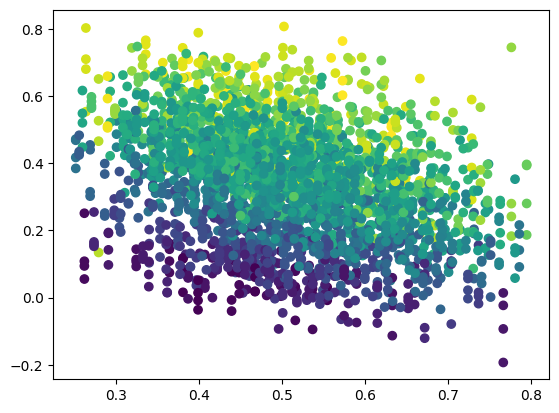

In [51]:
plt.scatter(params_LFI[:, 0], preds_LFI[:, 4], c=params_LFI[:, 1])


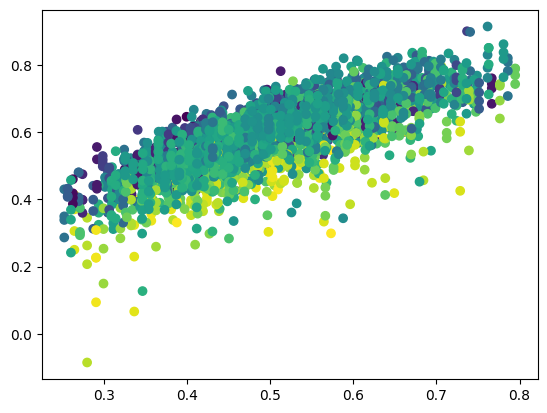

In [52]:
plt.scatter(params_test[:, 0], preds_LFI[:, 1], c=params_LFI[:, 1])
# plt.scatter(params_test[:, 1], preds_test[:, 0])


In [55]:
np.savez('formatted_7summaries_vic10_gelu_nolayernorm2',
         preds_LFI=preds_LFI,
         preds_val=preds_val,
         preds_test=preds_test,
         params_test=params_test,
         params_LFI=params_LFI,
         params_val=params_val,
         summs_baryons=scale_summs(torch.tensor(file['summs_baryons']), min_max),
         summs_no_baryons=scale_summs(torch.tensor(file['summs_no_baryons']), min_max),
         summs_target=scale_summs(torch.tensor(file['summs_target']), min_max),
         summ_min=min_max[0],
         summs_max=min_max[1])

In [7]:
ili

<module 'ili' from '/Users/lucas/venvs/ltu-ili/lib/python3.10/site-packages/ili/__init__.py'>

In [53]:
# SET UP BIJECTOR FOR SUMMARIES
torch.manual_seed(42)



val_start = preds_LFI.shape[0] - 1
train_idx = torch.arange(0, preds_LFI.shape[0] - 1)
val_idx = torch.arange(val_start, val_start + preds_val.shape[0] - 1)


low_ = torch.tensor(np.array(params_LFI).min(0)) - 0.01
high_ = torch.tensor(np.array(params_LFI).max(0)) + 0.01


# INVERSE NORMCDF TRANSFORMATION FOR BIJECTION θ -> ϕ
# normcdf_transform = dist.transforms.CumulativeDistributionTransform(dist.Normal(0, 1.0)).inv
# list_of_transforms = [
#                    normcdf_transform,
#                 dist.transforms.AffineTransform(loc=-low_, scale=torch.tensor(1. / (high_ - low_)),  event_dim=1), 
# ]

list_of_transforms = [dist.transforms.identity_transform] # PLACEHOLDER
bijector = dist.transforms.ComposeTransform(list_of_transforms)
phi_LFI = bijector(torch.tensor(params_LFI)).numpy()
phi_val = bijector(torch.tensor(params_val)).numpy()

prior = ili.utils.Uniform(low=phi_LFI.min(0), high=phi_LFI.max(0), device=device)



loader = NumpyLoader(x=np.concatenate([preds_LFI[:], preds_val[:]],0),
                     theta=np.concatenate([phi_LFI[:], phi_val[:]],0))


# loader = NumpyLoader(x=preds_LFI,
#                      theta=phi_LFI)


hidden = 200 # 100


# nets = [
#     ili.utils.load_nde_sbi(engine='NLE', model='maf', hidden_features=hidden, num_transforms=7), 
#     ili.utils.load_nde_sbi(engine='NLE', model='maf', hidden_features=hidden, num_transforms=8), 
#     ili.utils.load_nde_sbi(engine='NLE', model='maf', hidden_features=hidden, num_transforms=7), 
#     ili.utils.load_nde_sbi(engine='NLE', model='maf', hidden_features=hidden, num_transforms=8), 
# ]

num_transforms = 3

nets = [
    ili.utils.load_nde_sbi(engine='NLE', model='nsf', hidden_features=hidden, num_transforms=num_transforms), 
    ili.utils.load_nde_sbi(engine='NLE', model='maf', hidden_features=hidden, num_transforms=num_transforms + 3), 
    # ili.utils.load_nde_sbi(engine='NLE', model='maf', hidden_features=hidden, num_transforms=num_transforms), 
    # ili.utils.load_nde_sbi(engine='NLE', model='maf', hidden_features=hidden, num_transforms=num_transforms + 1), 
]


outdir = "./ndes_7summaries_vic_gelu_nolayernorm_nsf_hids%d_ntransf%d/"%(hidden, num_transforms)


# define training arguments
train_args = {
    'training_batch_size': 100,
    'learning_rate': 1.7e-5,
   # 'validation_fraction': 0.2,
    'stop_after_epochs': 40, # 30
}

# initialize the trainer
runner = InferenceRunner.load(
    backend='sbi',
    engine='NLE',
    prior=prior,
    nets=nets,
    device=device,
    train_args=train_args,
    proposal=None,
    out_dir=outdir,
    # train_indices=train_idx, # try this out
    # val_indices=val_idx
)

/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_36942/3642319551.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi_LFI = bijector(torch.tensor(params_LFI)).numpy()
/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_36942/3642319551.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi_val = bijector(torch.tensor(params_val)).numpy()


In [54]:
like_ensemble_reg, summs_reg = runner(loader=loader)
# save the bijector as well
save_obj(bijector, outdir + "bijector")

INFO:root:MODEL INFERENCE CLASS: NLE
INFO:root:Training model 1 / 2.


 Training neural network. Epochs trained: 371

INFO:root:Training model 2 / 2.


 Training neural network. Epochs trained: 668372 epochs.

/Users/lucas/venvs/ltu-ili/lib/python3.10/site-packages/sbi/utils/posterior_ensemble.py:142: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights = torch.tensor(weights) / sum(weights)
INFO:root:It took 826.7777810096741 seconds to train models.
INFO:root:Saving model to ndes_7summaries_vic_gelu_nolayernorm_nsf_hids200_ntransf3


 Neural network successfully converged after 669 epochs.

In [292]:
np.savez(outdir + 'formatted_summaries',
         preds_LFI=preds_LFI,
         preds_val=preds_val,
         preds_test=preds_test,
         params_test=params_test,
         params_LFI=params_LFI,
         params_val=params_val,
         # summs_baryons=scale_summs(torch.tensor(file['summs_baryons']), min_max),
         # summs_no_baryons=scale_summs(torch.tensor(file['summs_no_baryons']), min_max),
         summs_target=scale_summs(summs_target, min_max),
         summ_min=min_max[0],
         summs_max=min_max[1])

In [32]:
vlprb = [h["validation_log_probs"][-1] for h in summs_reg]
model_idx = np.argsort(vlprb)

model_idx

array([0])

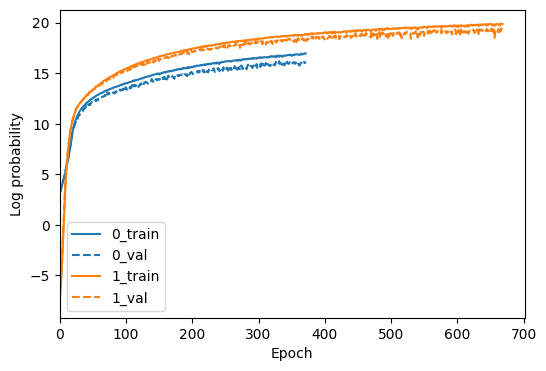

In [55]:
# plot train/validation loss
f, ax = plt.subplots(1, 1, figsize=(6,4))
c = list(mcolors.TABLEAU_COLORS)
for i, m in enumerate(summs_reg):
    ax.plot(m['training_log_probs'], ls='-', label=f"{i}_train", c=c[i])
    ax.plot(m['validation_log_probs'], ls='--', label=f"{i}_val", c=c[i])
ax.set_xlim(0)
ax.set_xlabel('Epoch')
ax.set_ylabel('Log probability')
ax.legend()

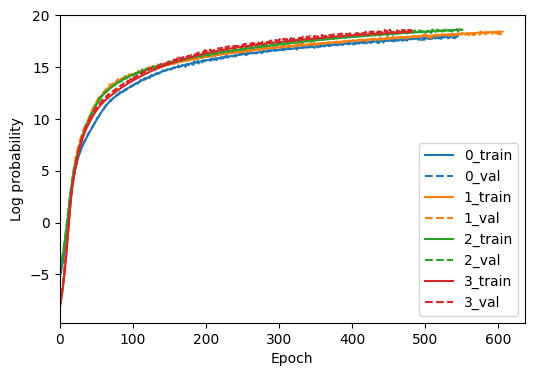

In [197]:
# plot train/validation loss
f, ax = plt.subplots(1, 1, figsize=(6,4))
c = list(mcolors.TABLEAU_COLORS)
for i, m in enumerate(summs_reg):
    ax.plot(m['training_log_probs'], ls='-', label=f"{i}_train", c=c[i])
    ax.plot(m['validation_log_probs'], ls='--', label=f"{i}_val", c=c[i])
ax.set_xlim(0)
ax.set_xlabel('Epoch')
ax.set_ylabel('Log probability')
ax.legend()

In [22]:
outdir = "/Users/lucas/repositories/compress-des/ndes_7summaries_vic_gelu_nolayernorm2/"
like_ensemble_reg = load_obj(outdir + "posterior.pkl")
bijector = load_obj(outdir + "bijector.pkl")


In [56]:
from affine_sample import *

low=phi_LFI.min(0);
high=phi_LFI.max(0)

def mask_prior_and_summaries(theta, summs, low=torch.tensor(low), high=torch.tensor(high)):
    condition = (~torch.any(theta.lt(low), keepdim=True, dim=-1)) & (~torch.any(theta.gt(high), keepdim=True, dim=-1))
    mask = condition.squeeze()
    return theta.float()[mask], summs.float()[mask], mask

def mask_prior(theta, low=torch.tensor(low), high=torch.tensor(high)):
    condition = (~torch.any(theta.lt(low), keepdim=True, dim=-1)) & (~torch.any(theta.gt(high), keepdim=True, dim=-1))
    mask = condition.squeeze()
    return theta.float()[mask], mask

def logprob(theta, x, likelihood_estimator):

    theta, mask = mask_prior(theta)
    lgp = likelihood_estimator.potential(theta.float(), 
                                          x=x.float())
    # replace theta not in prior with nan for later removal
    logp = torch.ones_like(mask) * torch.nan
    logp[mask] = lgp
    return logp



def compute_systematic_shift2(chain1, chain2, inds=[0,1], thin=1):
    chain1 = chain1[-start::thin, inds]
    chain2 = chain2[-start::thin, inds]

    diff = (chain1.mean(0) - chain2.mean(0))
    # std  = np.linalg.inv(np.cov(chain1[:, :], rowvar=False))
    std  = np.linalg.inv((np.cov(chain1, rowvar=False) + np.cov(chain2, rowvar=False) / 2.))

    return np.sqrt(diff @ std @ diff.T)


In [57]:
theta_fid = np.array([0.27, 0.83, -1.0])
theta_fid = np.array([0.33, 0.75, -0.75])


target_indexA = np.argmin(np.sum((inv_scale_params(np.array(params_LFI)) - theta_fid)**2, 1))

print(target_indexA)

target_x_A = preds_test[target_indexA] 
target_theta = inv_scale_params(np.array(params_LFI))[target_indexA]

target_theta

2716


array([ 0.33142486,  0.7457282 , -0.7442385 ], dtype=float32)

In [58]:
from copy import deepcopy

def get_mcmc_chains(target, 
                    std=1e-2, 
                    n_steps=4000, 
                    burnin=500, 
                    w_cutoff=-1.0, 
                    thin = 1,
                    n_walkers=500,
                    like_ensemble=like_ensemble_reg,
                    theta0 = phi_val.mean(0), ensemble_members=None):

    like_est = deepcopy(like_ensemble)

    if ensemble_members is not None:
        like_est.posteriors = [like_est.posteriors[q] for q in ensemble_members]
        like_est.weights = torch.tensor([like_est.weights[q] for q in ensemble_members])
    else:
        like_est = like_est

    logp = lambda t: logprob(t, x=torch.tensor(target), 
                             likelihood_estimator=like_est)    
    
    walkers1 = torch.normal(mean=0, std=std, size=[n_walkers, 3]) + torch.tensor(theta0)
    walkers2 = torch.normal(mean=0, std=std, size=[n_walkers, 3]) + torch.tensor(theta0)
    
    chainreg = affine_sample(logp, n_params=3, n_walkers=n_walkers, 
              n_steps=n_steps, walkers1=walkers1, walkers2=walkers2, progress_bar=True)

    print(chainreg.shape)

    chainreg = chainreg[burnin::thin, :, :].reshape(-1, 3)
    
    
    # invert bijector
    chainreg = bijector.inv(torch.tensor(chainreg))
    # convert back to real parameter values
    chainreg = torch.tensor(inv_scale_params(chainreg.numpy()))
    
    chainreg,_ = mask_prior(chainreg, low=torch.tensor([0.15, 0.5, w_cutoff]), high=torch.tensor([0.52, 1.0, -0.3333]))
    cut = np.all(~np.isnan(chainreg.numpy()), axis=-1)
    chainreg = chainreg.numpy()[cut,:]

    return chainreg

In [59]:
like_ensemble_reg.weights

tensor([0.0375, 0.9625])

In [60]:

def get_mcmc_chains_n(target, 
                    seed,
                    n_chains = 3,
                    std=1e-2, 
                    n_steps=4000, 
                    burnin=500, 
                    w_cutoff=-1.0, 
                    thin = 4,
                    n_walkers=500,
                    theta0 = phi_val.mean(0), 
                    like_ensemble=like_ensemble_reg,
                    ensemble_members=None,
                    cat_chains=False,
                      ):
    chains = []
    for i in range(n_chains):
        print('running chain %d of %d'%(i+1, n_chains))
        seed += 1
        torch.manual_seed(seed)
        chain = get_mcmc_chains(target=target, 
                        std=std, 
                        n_steps=n_steps, 
                        burnin=burnin, 
                        w_cutoff=w_cutoff, 
                        thin = thin,
                        n_walkers=n_walkers,
                        theta0 = theta0, 
                        like_ensemble=like_ensemble,
                        ensemble_members=ensemble_members)
        chains.append(chain)
        
    
    if cat_chains:
        return np.concatenate(chains, 0)
    
    else:
        return chains

In [61]:
testchain = get_mcmc_chains_n(target_x_A, 
                                 0,
                                 n_chains=4,
                                 std=0.2, 
                                 n_steps=100, 
                                 thin=3,
                                 n_walkers=500,
                                 burnin=50, w_cutoff=-1.0, theta0 = phi_val.mean(0),
                                 cat_chains=True,
                                 ensemble_members=None ) #model_idx[:4])

running chain 1 of 4


  0%|                                                                                                       | 0/99 [00:00<?, ?it/s]/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_36942/3843577282.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logp = lambda t: logprob(t, x=torch.tensor(target),
100%|██████████████████████████████████████████████████████████████████████████████████████████████| 99/99 [00:05<00:00, 19.15it/s]
/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_36942/3843577282.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  chainreg = bijector.inv(torch.tensor(chainreg))


torch.Size([100, 1000, 3])
running chain 2 of 4


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 99/99 [00:04<00:00, 21.56it/s]


torch.Size([100, 1000, 3])
running chain 3 of 4


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 99/99 [00:04<00:00, 20.45it/s]


torch.Size([100, 1000, 3])
running chain 4 of 4


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 99/99 [00:04<00:00, 20.65it/s]

torch.Size([100, 1000, 3])


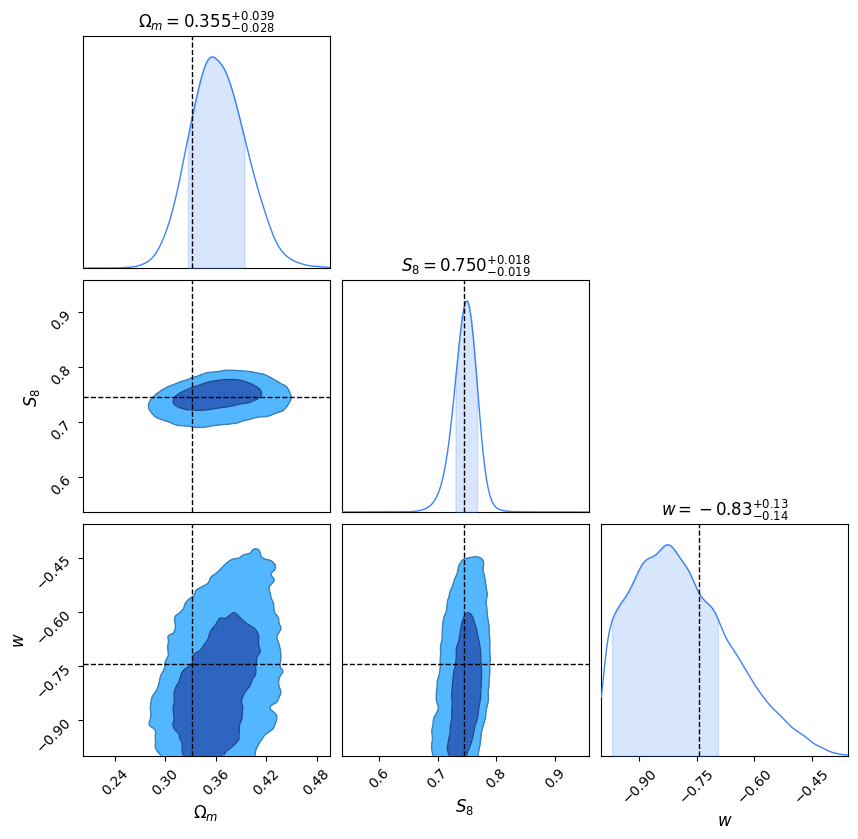

In [62]:
param_labels = [r'$\Omega_m$', r'$S_8$', r'$w$']

dfreg = pd.DataFrame(testchain[10000::1], columns=param_labels)

c = ChainConsumer()
c.add_chain(Chain(samples=dfreg, name=r"MDN($C_\ell$ + A) compress to 6 numbers",))

c.add_truth(Truth(location={param_labels[0]: target_theta[0], 
                            param_labels[1]: target_theta[1], 
                            param_labels[2]: target_theta[2]}))

fig = c.plotter.plot()
plt.show()

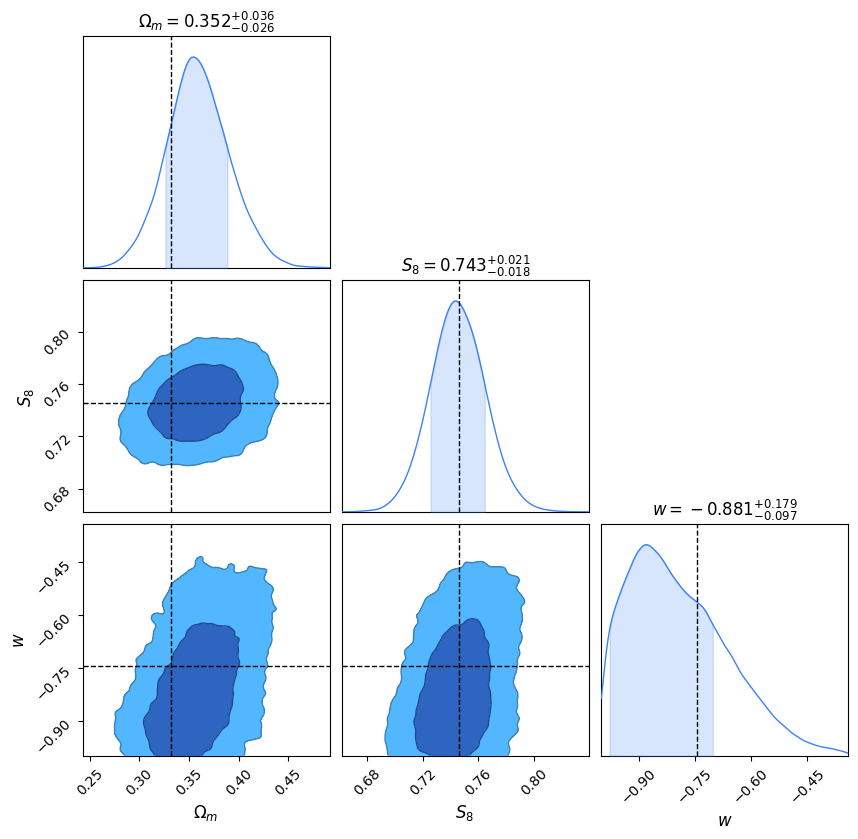

In [78]:
param_labels = [r'$\Omega_m$', r'$S_8$', r'$w$']

dfreg = pd.DataFrame(testchain[10000::7], columns=param_labels)

c = ChainConsumer()
c.add_chain(Chain(samples=dfreg, name=r"MDN($C_\ell$ + A) compress to 6 numbers",))

c.add_truth(Truth(location={param_labels[0]: target_theta[0], 
                            param_labels[1]: target_theta[1], 
                            param_labels[2]: target_theta[2]}))

fig = c.plotter.plot()
plt.show()

# check baryon simulations

In [63]:
theta_true_baryons = get_S8(np.array([[0.26, 0.84, -1.0]])).squeeze()

In [64]:
theta_true_baryons

array([ 0.26      ,  0.78199744, -1.        ])

In [65]:
file['summs_baryons'].shape

(128, 7)

In [66]:
summs_no_baryons = scale_summs(torch.tensor(file['summs_no_baryons']), min_max)
summs_baryons = scale_summs(torch.tensor(file['summs_baryons']), min_max)


res0 = (((summs_no_baryons - summs_no_baryons.mean(0)) / summs_no_baryons)[:, 0])
res1 = (((summs_no_baryons - summs_no_baryons.mean(0)) / summs_no_baryons)[:, 1])


mask = res0 < 0.5
# mask &= res1 < 1

mask.sum()

tensor(128)

In [67]:
mask.shape

torch.Size([128])

In [68]:
summs_no_baryons = scale_summs(torch.tensor(file['summs_no_baryons']),min_max) #[mask]
summs_baryons = scale_summs(torch.tensor(file['summs_baryons']), min_max) #[mask]


logp_mean = like_ensemble_reg.log_prob(torch.tensor(scale_params(theta_true_baryons[np.newaxis, :]), dtype=torch.float), 
                                       x=torch.tensor(summs_no_baryons.mean(0), dtype=torch.float))



logps_nobaryons = np.array([
    np.array(like_ensemble_reg.log_prob(torch.tensor(scale_params(theta_true_baryons[np.newaxis, :]), dtype=torch.float), \
                                        x=torch.tensor(summs_no_baryons[l], dtype=torch.float))) for l in range(summs_no_baryons.shape[0])]).squeeze()


logps_baryons = np.array([
    np.array(like_ensemble_reg.log_prob(torch.tensor(scale_params(theta_true_baryons[np.newaxis, :]), dtype=torch.float), \
                                        x=torch.tensor(summs_baryons[l], dtype=torch.float))) for l in range(summs_baryons.shape[0])]).squeeze()

print("average log_prob for no_baryon test set: %.3f"%(logps_nobaryons.mean()))
print("average log_prob for baryon test set: %.3f"%(logps_baryons.mean()))
print("average log_prob for mean vector: %.3f"%(logp_mean))



# weight the average by the log_prob:

logp_weighted_avg_baryon = np.average(summs_baryons, weights = np.exp(logps_nobaryons), axis=0)
logp_weighted_avg_nobaryon = np.average(summs_no_baryons, weights = np.exp(logps_nobaryons), axis=0)

print(logp_weighted_avg_baryon)
print(logp_weighted_avg_nobaryon)



logp_mean = like_ensemble_reg.log_prob(torch.tensor(scale_params(theta_true_baryons[np.newaxis, :]), dtype=torch.float), 
                                       x=torch.tensor(logp_weighted_avg_nobaryon, dtype=torch.float))


print("average log_prob for no_baryon test set: %.3f"%(logps_nobaryons.mean()))
print("average log_prob for baryon test set: %.3f"%(logps_baryons.mean()))
print("average log_prob for weighted mean vector: %.3f"%(logp_mean))

/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_36942/3870513493.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x=torch.tensor(summs_no_baryons.mean(0), dtype=torch.float))
/Users/lucas/venvs/ltu-ili/lib/python3.10/site-packages/sbi/inference/posteriors/mcmc_posterior.py:172: UserWarning: `.log_prob()` is deprecated for methods that can only evaluate the
            log-probability up to a normalizing constant. Use `.potential()` instead.
  warn(
/Users/lucas/venvs/ltu-ili/lib/python3.10/site-packages/sbi/inference/posteriors/mcmc_posterior.py:176: UserWarning: The log-probability is unnormalized!
  warn("The log-probability is unnormalized!")
/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_36942/3870513493.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detac

average log_prob for no_baryon test set: 24.222
average log_prob for baryon test set: 23.873
average log_prob for mean vector: 16.030
[0.13380766 0.54042053 0.57021636 0.22554058 0.421078   0.457624
 0.4712887 ]
[0.14418384 0.544362   0.5499686  0.23352987 0.43076593 0.45609233
 0.47354022]
average log_prob for no_baryon test set: 24.222
average log_prob for baryon test set: 23.873
average log_prob for weighted mean vector: 19.474


In [26]:
128 / 16

8.0

In [27]:
n_steps = 2000
burnin = 1000
n_walkers = 100

In [34]:
n_steps = 500
burnin = 250
n_walkers = 500

chains_baryon_mean_noweights = get_mcmc_chains_n(np.average(summs_baryons, 0, 
                                                           weights=np.exp(logps_nobaryons)
                                                           ), 
                                     0,
                                     std=0.05, 
                                     n_chains=3,
                                     n_steps=n_steps, 
                                     thin=3,
                                     n_walkers=n_walkers,
                                     burnin=burnin, w_cutoff=-1.0, theta0 = scale_params(theta_true_baryons[np.newaxis, :]),
                                     cat_chains=True,
                                     ensemble_members=None)

chains_no_baryon_mean_noweights = get_mcmc_chains_n(np.average(summs_no_baryons, 0,  
                                                              weights = np.exp(logps_nobaryons)
                                                              ),
                                     0,
                                     std=0.05, 
                                     n_chains=3,
                                     n_steps=n_steps, 
                                     thin=3,
                                     n_walkers=n_walkers,
                                     burnin=burnin, w_cutoff=-1.0, theta0 = scale_params(theta_true_baryons[np.newaxis, :]),
                                     cat_chains=True,
                                     ensemble_members=None)

running chain 1 of 3


100%|████████████████████████████████████████████████████████████████████████████████████████████| 499/499 [00:25<00:00, 19.58it/s]
/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_12448/3843577282.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  chainreg = bijector.inv(torch.tensor(chainreg))


torch.Size([500, 1000, 3])
running chain 2 of 3


100%|████████████████████████████████████████████████████████████████████████████████████████████| 499/499 [00:24<00:00, 20.09it/s]


torch.Size([500, 1000, 3])
running chain 3 of 3


...

torch.Size([500, 1000, 3])
running chain 2 of 3


100%|████████████████████████████████████████████████████████████████████████████████████████████| 499/499 [00:24<00:00, 20.32it/s]


torch.Size([500, 1000, 3])
running chain 3 of 3


100%|████████████████████████████████████████████████████████████████████████████████████████████| 499/499 [00:25<00:00, 19.83it/s]

torch.Size([500, 1000, 3])


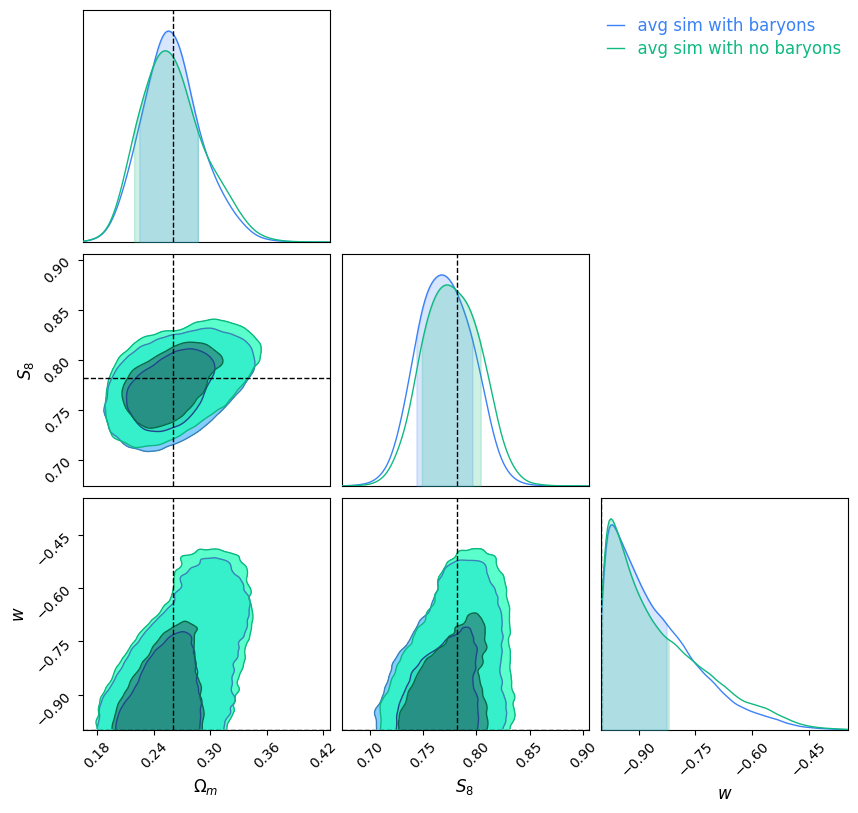

In [35]:
param_labels = [r'$\Omega_m$', r'$S_8$', r'$w$']

c = ChainConsumer()

thin = 2

start = 20000
kde = False

df = pd.DataFrame(chains_baryon_mean_noweights[start::thin], columns=param_labels)
c.add_chain(Chain(samples=df, name="avg sim with baryons", kde=kde))

df = pd.DataFrame(chains_no_baryon_mean_noweights[start::thin], columns=param_labels)
c.add_chain(Chain(samples=df, name="avg sim with no baryons", kde=kde))

c.add_truth(Truth(location={param_labels[0]: theta_true_baryons[0], 
                            param_labels[1]: theta_true_baryons[1], 
                            param_labels[2]: theta_true_baryons[2]}))
fig = c.plotter.plot()
plt.show()

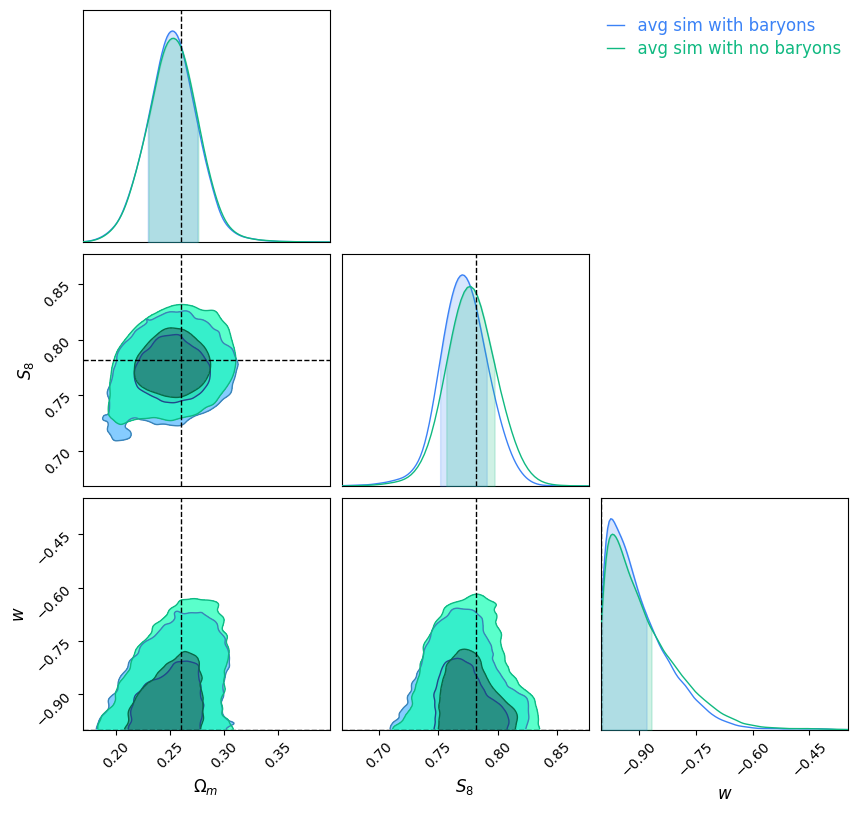

In [69]:
param_labels = [r'$\Omega_m$', r'$S_8$', r'$w$']

c = ChainConsumer()

thin = 2

start = 20000
kde = False

df = pd.DataFrame(chains_baryon_mean_noweights[start::thin], columns=param_labels)
c.add_chain(Chain(samples=df, name="avg sim with baryons", kde=kde))

df = pd.DataFrame(chains_no_baryon_mean_noweights[start::thin], columns=param_labels)
c.add_chain(Chain(samples=df, name="avg sim with no baryons", kde=kde))

c.add_truth(Truth(location={param_labels[0]: theta_true_baryons[0], 
                            param_labels[1]: theta_true_baryons[1], 
                            param_labels[2]: theta_true_baryons[2]}))
fig = c.plotter.plot()
plt.show()

In [36]:
print("percent shift in means: ", compute_systematic_shift2(chains_baryon_mean_noweights.reshape(-1, 3), 
                                                            chains_no_baryon_mean_noweights.reshape(-1,3), thin=7))

percent shift in means:  0.2746554528407887


In [23]:
n_walkers=500
n_steps=500
burnin = 250

testsim = get_mcmc_chains_n(scale_summs(torch.tensor(file['summs_baryons']), min_max=min_max)[43], 
                                     seed=9,
                                     std=0.1, 
                                     n_steps=n_steps, 
                                     n_chains=4,
                                     thin=3,
                                     n_walkers=500,
                                     burnin=burnin, w_cutoff=-1.0, theta0 = scale_params(theta_true_baryons[np.newaxis, :]),
                                     cat_chains=True,
                                     ensemble_members=None)

# testsim_nobary = get_mcmc_chains_n(scale_summs(torch.tensor(file['summs_no_baryons']), mean_std=mean_std)[49], 
#                                      seed=9,
#                                      std=0.1, 
#                                      n_steps=n_steps, 
#                                      thin=3,
#                                      n_walkers=100,
#                                      burnin=burnin, w_cutoff=-1.0, theta0 = scale_params(theta_true_baryons[np.newaxis, :]),
#                                      cat_chains=True,
#                                      ensemble_members=None)

running chain 1 of 4


  0%|                                                                                                               | 0/499 [00:00<?, ?it/s]/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_36942/3843577282.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logp = lambda t: logprob(t, x=torch.tensor(target),
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 499/499 [00:11<00:00, 41.88it/s]
/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_36942/3843577282.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  chainreg = bijector.inv(torch.tensor(chainreg))


torch.Size([500, 1000, 3])
running chain 2 of 4


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 499/499 [00:12<00:00, 41.02it/s]


torch.Size([500, 1000, 3])
running chain 3 of 4


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 499/499 [00:12<00:00, 39.92it/s]


torch.Size([500, 1000, 3])
running chain 4 of 4


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 499/499 [00:11<00:00, 42.24it/s]


torch.Size([500, 1000, 3])


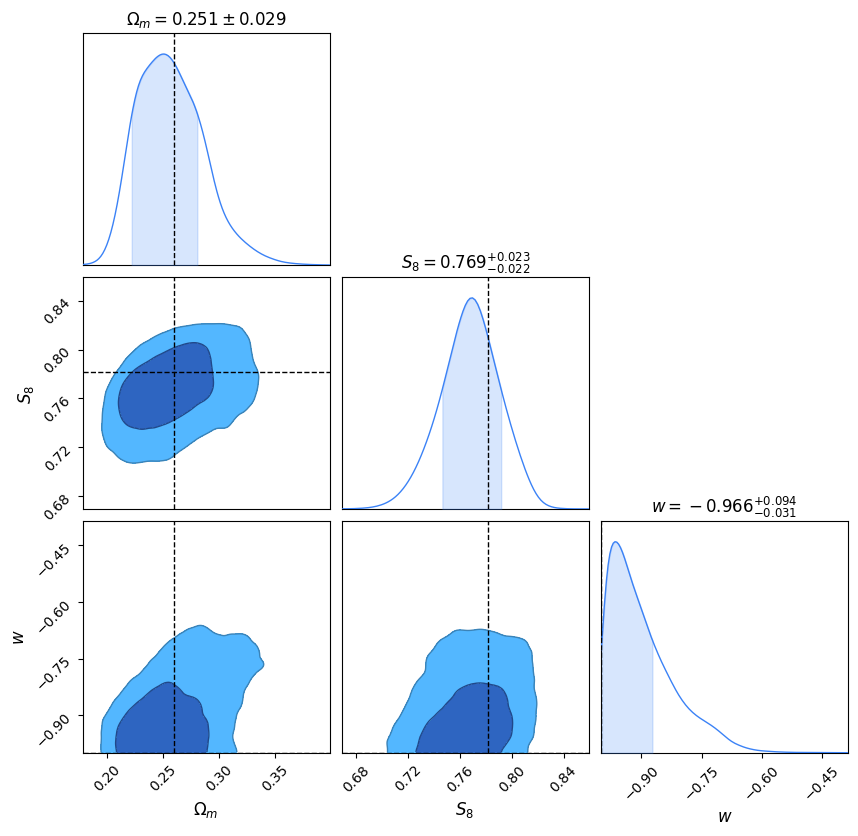

In [24]:
param_labels = [r'$\Omega_m$', r'$S_8$', r'$w$']

c = ChainConsumer()

thin = 1

start = 0

# df = pd.DataFrame(testsim_pkonly[start::thin], columns=param_labels)
# c.add_chain(Chain(samples=df, name="pk only, 5 summaries",))

df = pd.DataFrame(testsim[start::thin], columns=param_labels)
c.add_chain(Chain(samples=df, name="hybrid, 7 summaries",))

#df = pd.DataFrame(testsim_nobary[start::thin], columns=param_labels)
#c.add_chain(Chain(samples=df, name="avg sim with no baryons",))

c.add_truth(Truth(location={param_labels[0]: theta_true_baryons[0], 
                            param_labels[1]: theta_true_baryons[1], 
                            param_labels[2]: theta_true_baryons[2]}))
fig = c.plotter.plot()
plt.show()

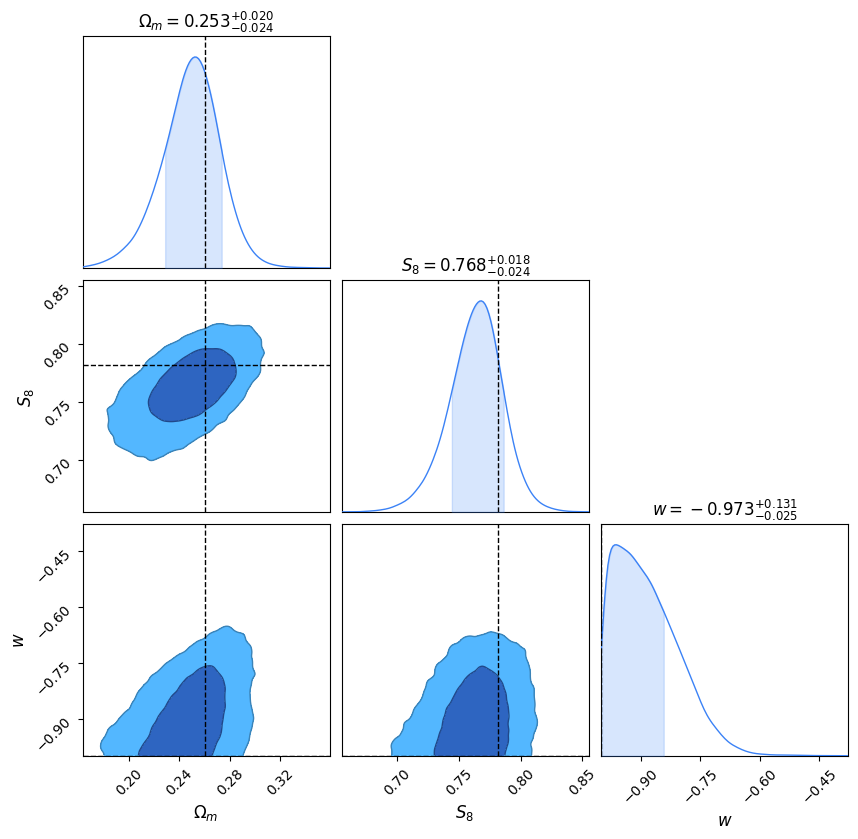

In [26]:
param_labels = [r'$\Omega_m$', r'$S_8$', r'$w$']

c = ChainConsumer()

thin = 1

start = 0

# df = pd.DataFrame(testsim_pkonly[start::thin], columns=param_labels)
# c.add_chain(Chain(samples=df, name="pk only, 5 summaries",))

df = pd.DataFrame(testsim[start::thin], columns=param_labels)
c.add_chain(Chain(samples=df, name="hybrid, 7 summaries",))

#df = pd.DataFrame(testsim_nobary[start::thin], columns=param_labels)
#c.add_chain(Chain(samples=df, name="avg sim with no baryons",))

c.add_truth(Truth(location={param_labels[0]: theta_true_baryons[0], 
                            param_labels[1]: theta_true_baryons[1], 
                            param_labels[2]: theta_true_baryons[2]}))
fig = c.plotter.plot()
plt.show()

In [69]:
def get_mcmc_chains_n_blinded(target, 
                    seed,
                    n_chains = 3,
                    std=1e-2, 
                    n_steps=4000, 
                    burnin=500, 
                    w_cutoff=-2.0, 
                    thin = 4,
                    n_walkers=500,
                    theta0 = phi_val.mean(0), 
                    ensemble_members=None,
                    like_ensemble=like_ensemble_reg,
                    cat_chains=False,
                      ):
    chains = []
    for i in range(n_chains):
        print('running chain %d of %d'%(i+1, n_chains))
        seed += 1
        torch.manual_seed(seed)
        chain = get_mcmc_chains(target=target, 
                        std=std, 
                        n_steps=n_steps, 
                        burnin=burnin, 
                        w_cutoff=w_cutoff, 
                        thin = thin,
                        n_walkers=n_walkers,
                        like_ensemble=like_ensemble_reg,
                        theta0 = theta0, 
                        ensemble_members=ensemble_members)
        chains.append(chain)
        
    
    if cat_chains:
        return np.concatenate(chains, 0) + (np.random.random(size = (3,)) * np.random.randint(1, 100))
    
    else:
        return chains + (np.random.random(size = (3,)) * np.random.randint(1, 100))

In [70]:
preds_LFI.shape

torch.Size([2828, 7])

In [80]:
target_blind = get_mcmc_chains_n(scale_summs(summs_target, min_max),
                                     seed=42,
                                     n_chains=6,
                                     std=0.05, 
                                     n_steps=3000, 
                                     thin=1,
                                     n_walkers=100,
                                     burnin=1000, 
                                     w_cutoff=-1.0, 
                                     theta0 = scale_params(theta_true_baryons[np.newaxis, :]),
                                     cat_chains=False,
                                     ensemble_members=None)

running chain 1 of 6


  0%|                                                                                                     | 0/2999 [00:00<?, ?it/s]/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_36942/3843577282.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logp = lambda t: logprob(t, x=torch.tensor(target),
100%|██████████████████████████████████████████████████████████████████████████████████████████| 2999/2999 [00:57<00:00, 52.25it/s]
/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_36942/3843577282.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  chainreg = bijector.inv(torch.tensor(chainreg))


torch.Size([3000, 200, 3])
running chain 2 of 6


100%|██████████████████████████████████████████████████████████████████████████████████████████| 2999/2999 [00:56<00:00, 53.25it/s]


torch.Size([3000, 200, 3])
running chain 3 of 6


...

torch.Size([3000, 200, 3])
running chain 5 of 6


100%|██████████████████████████████████████████████████████████████████████████████████████████| 2999/2999 [00:57<00:00, 52.36it/s]


torch.Size([3000, 200, 3])
running chain 6 of 6


100%|██████████████████████████████████████████████████████████████████████████████████████████| 2999/2999 [00:55<00:00, 53.80it/s]


torch.Size([3000, 200, 3])


In [71]:
target_blind = get_mcmc_chains_n(scale_summs(summs_target, min_max),
                                     seed=42,
                                     n_chains=6, # 6
                                     std=0.05, 
                                     n_steps=500, # 3000
                                     thin=1,
                                     n_walkers=100,
                                     burnin=250, # 1000
                                     w_cutoff=-1.0, 
                                     theta0 = scale_params(theta_true_baryons[np.newaxis, :]),
                                     like_ensemble=like_ensemble_reg,
                                     cat_chains=False,
                                     ensemble_members=None)

running chain 1 of 6


  0%|                                                                                                      | 0/499 [00:00<?, ?it/s]/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_36942/3843577282.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logp = lambda t: logprob(t, x=torch.tensor(target),
100%|████████████████████████████████████████████████████████████████████████████████████████████| 499/499 [00:10<00:00, 49.85it/s]
/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_36942/3843577282.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  chainreg = bijector.inv(torch.tensor(chainreg))


torch.Size([500, 200, 3])
running chain 2 of 6


100%|████████████████████████████████████████████████████████████████████████████████████████████| 499/499 [00:09<00:00, 52.56it/s]


torch.Size([500, 200, 3])
running chain 3 of 6


...

torch.Size([500, 200, 3])
running chain 5 of 6


100%|████████████████████████████████████████████████████████████████████████████████████████████| 499/499 [00:09<00:00, 52.49it/s]


torch.Size([500, 200, 3])
running chain 6 of 6


100%|████████████████████████████████████████████████████████████████████████████████████████████| 499/499 [00:09<00:00, 52.60it/s]

torch.Size([500, 200, 3])


In [81]:
target_blind0 = deepcopy(target_blind)

In [82]:
target_blind0[0][:].shape

(384120, 3)

In [83]:
target_blind = np.concatenate([c[-40_000:, :] for c in target_blind0], 0)

In [84]:
# np.savez("hybrid_chains_Y3_postunblind_7summs_gelu_nolayernorm_1",
#         chains=np.stack([c[-100_000:, :] for c in target_blind0])
#         )
         

In [85]:
target_blind.shape

(240000, 3)

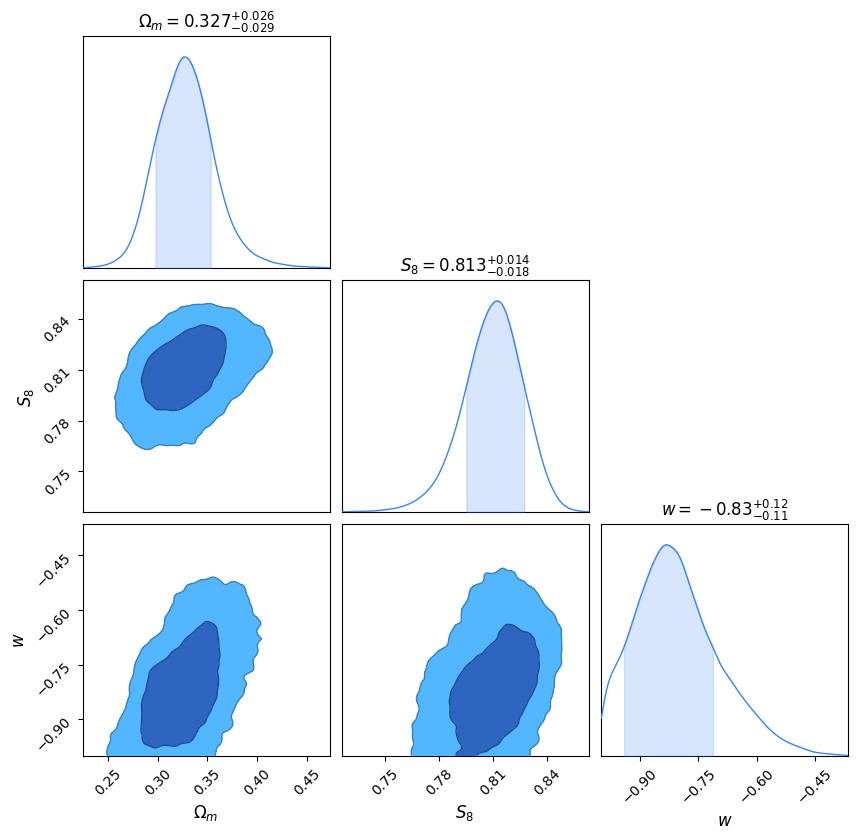

In [86]:
param_labels = [r'$\Omega_m$', r'$S_8$', r'$w$']

c = ChainConsumer()

thin = 3

start = 0

df = pd.DataFrame(target_blind[::thin][start:, :], columns=param_labels[:])
c.add_chain(Chain(samples=df, name="avg sim with baryons", kde=False))

fig = c.plotter.plot()
plt.show()

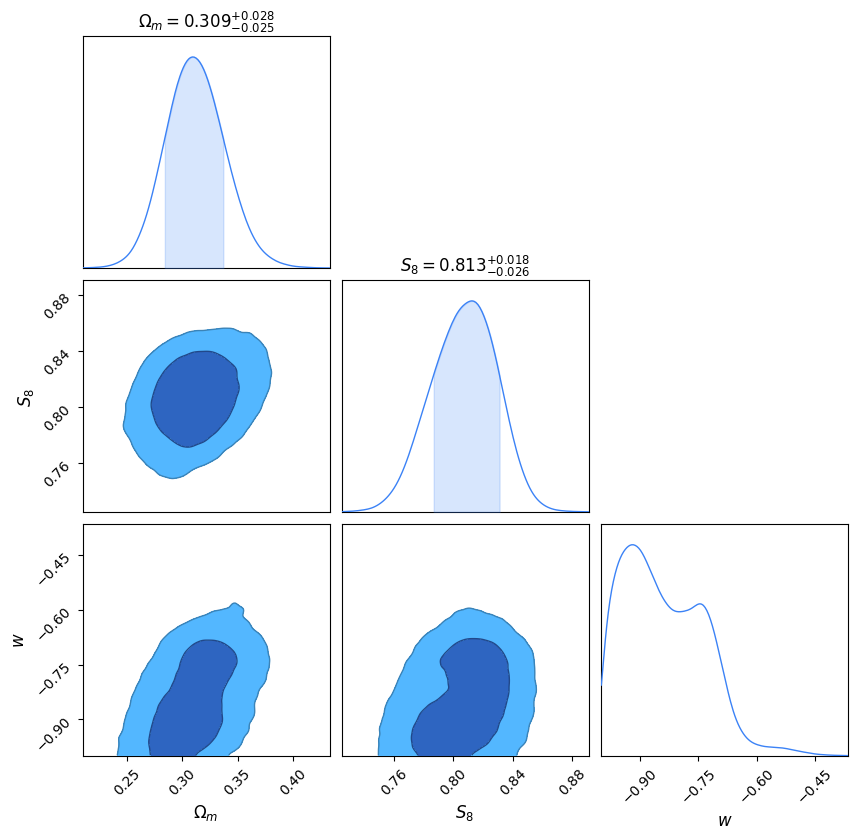

In [38]:
param_labels = [r'$\Omega_m$', r'$S_8$', r'$w$']

c = ChainConsumer()

thin = 2

start = 0

df = pd.DataFrame(target_blind[::thin][start:, :], columns=param_labels[:])
c.add_chain(Chain(samples=df, name="avg sim with baryons", kde=False))

fig = c.plotter.plot()
plt.show()

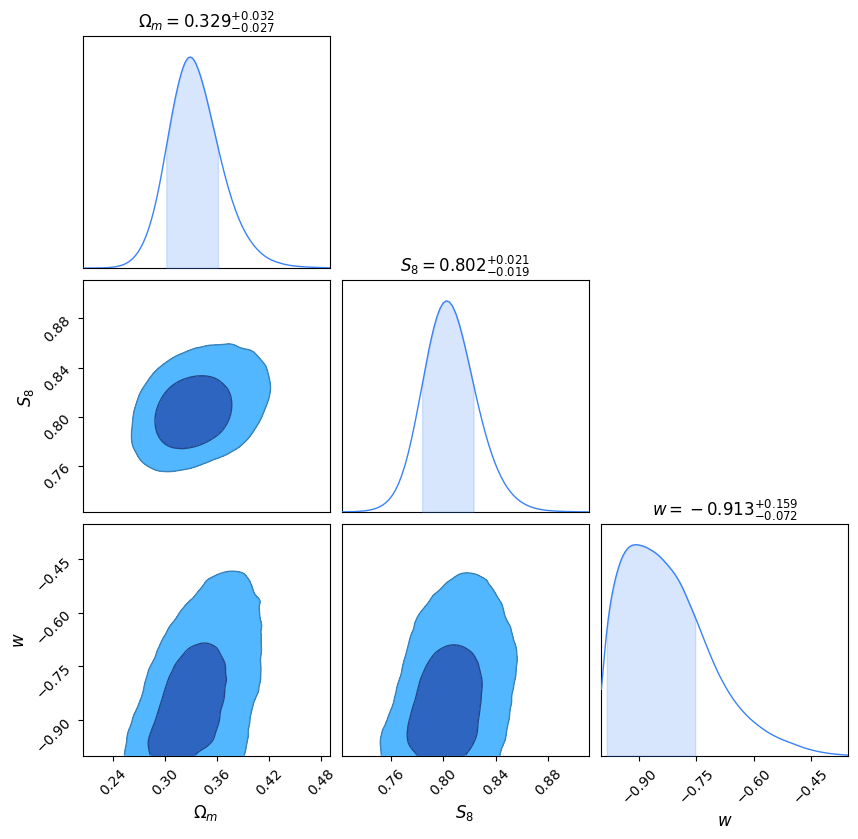

In [66]:
param_labels = [r'$\Omega_m$', r'$S_8$', r'$w$']

c = ChainConsumer()

thin = 1

start = 0

df = pd.DataFrame(target_blind[::thin][start:, :], columns=param_labels[:])
c.add_chain(Chain(samples=df, name="avg sim with baryons", kde=False))

fig = c.plotter.plot()
plt.show()

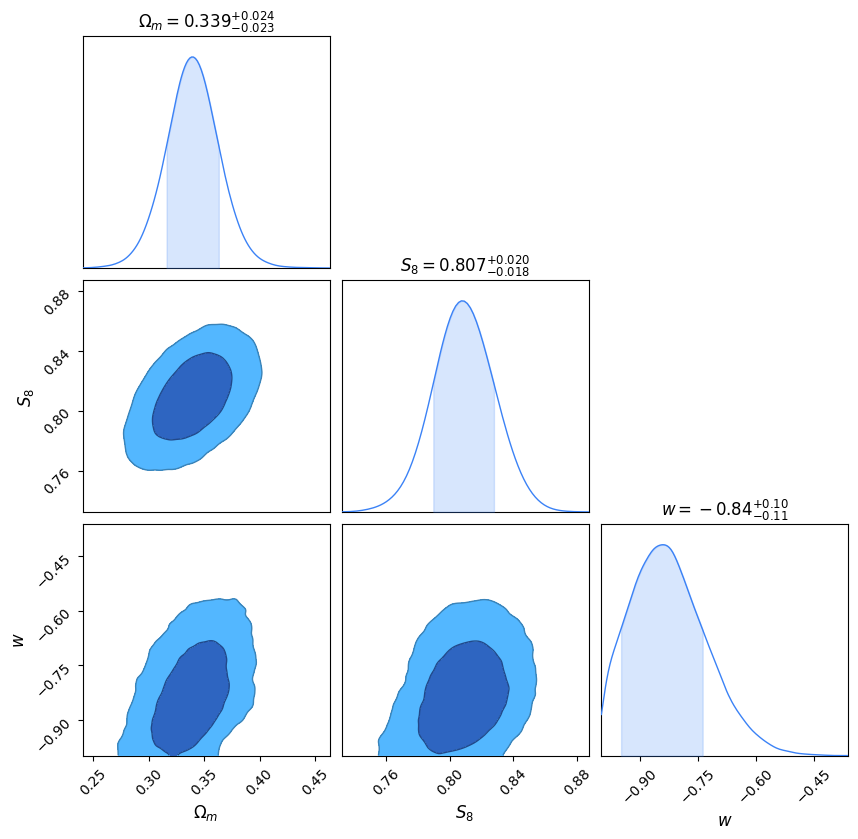

In [67]:
param_labels = [r'$\Omega_m$', r'$S_8$', r'$w$']

c = ChainConsumer()

thin = 17

start = 0

df = pd.DataFrame(target_blind[::thin][start:, :], columns=param_labels[:])
c.add_chain(Chain(samples=df, name="avg sim with baryons", kde=False))

fig = c.plotter.plot()
plt.show()

In [311]:
target_blind_singles = [get_mcmc_chains_n(scale_summs(torch.tensor(file['summs_target']), min_max), 
                                     seed=10,
                                     n_chains=1,
                                     std=0.02, 
                                     n_steps=500, 
                                     thin=1,
                                     n_walkers=500,
                                     burnin=250, w_cutoff=-1.0, theta0 = scale_params(theta_true_baryons[np.newaxis, :]),
                                     like_ensemble=like_ensemble_reg.posteriors[j],
                                     cat_chains=True,
                                     ensemble_members=None) for j in range(4)]

running chain 1 of 1


  0%|                                                                                                               | 0/499 [00:00<?, ?it/s]/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_20048/3843577282.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logp = lambda t: logprob(t, x=torch.tensor(target),
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 499/499 [00:17<00:00, 28.62it/s]
/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_20048/3843577282.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  chainreg = bijector.inv(torch.tensor(chainreg))


torch.Size([500, 1000, 3])
running chain 1 of 1


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 499/499 [00:21<00:00, 23.66it/s]


torch.Size([500, 1000, 3])
running chain 1 of 1


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 499/499 [00:16<00:00, 29.62it/s]


torch.Size([500, 1000, 3])
running chain 1 of 1


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 499/499 [00:20<00:00, 24.40it/s]


torch.Size([500, 1000, 3])


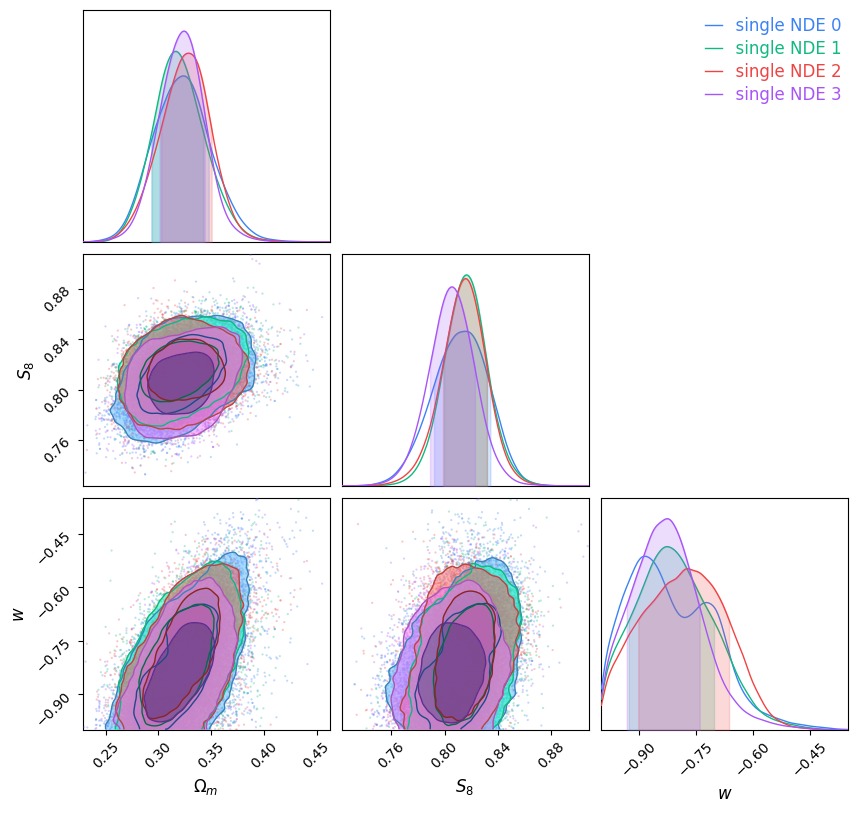

In [312]:
param_labels = [r'$\Omega_m$', r'$S_8$', r'$w$']

c = ChainConsumer()

thin = 1
upto = 3


start = 0

for j in range(4):
    df = pd.DataFrame(target_blind_singles[j][start::thin, :upto], columns=param_labels[:upto])
    c.add_chain(Chain(samples=df, name="single NDE %d"%(j), plot_cloud=True, kde=False))

fig = c.plotter.plot()
plt.show()

In [83]:
pwd

'/Users/lucas/repositories/des-hybrid/density_estimation/local_testing'

Removed no burn in
Removed no burn in
Removed no burn in
old improvment over Niall:  1.5836866011196207
improvment over Niall:  1.2739835259629018


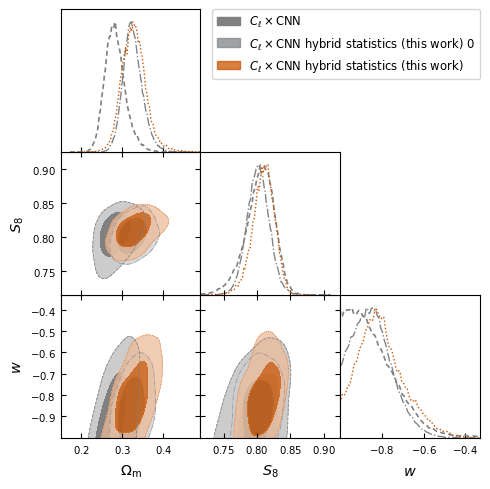

In [87]:
import getdist
from getdist import plots, MCSamples
colors = [ 'gray', 
         "#818589",
        "#cc5500", # burnt orange
           "#3c77e4",
         ]




prior_om = [0.15, 0.49]
prior_s8 = [0.5, 1.]
prior_w = [-1, -0.33]
prior_IA = [-3, 3.]

names = ['Om', 's8', 'w']
labels = [r'\Omega_{\rm m}', 'S_8', 'w']
ranges = {'Om': prior_om, 's8': prior_s8, 'w': prior_w}

n_burn2d = 0
burnin_niall = 0
hybrid = target_blind[::9]

niall = np.load("/Users/lucas/repositories/des-hybrid/results/cl_cnn_samples_publication_version_niall.npy").squeeze()
hybrid0 = np.load("/Users/lucas/repositories/des-hybrid/results/desy3_hybrid_unblinding_6chains_20_11_25.npy").squeeze()



samples_niall = MCSamples(samples=[niall[:, burnin_niall:,0].flatten(),
                                   niall[:, burnin_niall:,1].flatten(), 
                                   niall[:, burnin_niall:,2].flatten(), 
                                  ],
                     names=['Om', 's8','w'],
                     labels=labels,
                    label=r'$C_\ell\times$CNN',
                    settings={'mult_bias_correction_order': 1,
                             'smooth_scale_2D': 0.4,
                             'smooth_scale_1D': 0.05},
                    ranges=ranges)

samples_hybrid0 = MCSamples(samples=[hybrid0[burnin_niall:,:,0].flatten(),
                                    hybrid0[burnin_niall:,:,1].flatten(), 
                                    hybrid0[burnin_niall:,:,2].flatten()],
                     names=['Om', 's8','w'],
                     labels=labels,
                    label=r'$C_\ell \times $CNN hybrid statistics (this work) 0',
                    settings={'mult_bias_correction_order': 1,
                              'smooth_scale_2D': 0.4,
                              'smooth_scale_1D': 0.05},
                    ranges=ranges)

samples_hybrid = MCSamples(samples=[hybrid[burnin_niall:,0].flatten(),
                                    hybrid[burnin_niall:,1].flatten(), 
                                    hybrid[burnin_niall:,2].flatten()],
                     names=['Om', 's8','w'],
                     labels=labels,
                    label=r'$C_\ell \times $CNN hybrid statistics (this work)',
                    settings={'mult_bias_correction_order': 1,
                              'smooth_scale_2D': 0.4,
                              'smooth_scale_1D': 0.05},
                    ranges=ranges)


# Plot settings
param_limits_plot = {
        'Om': (0.15, 0.49),
        's8': (0.715, 0.925),
        #'s8': (0.5, 1.2),
        'w': (-1, -0.33),
        'IA': (-2, 2)
    }

print("old improvment over Niall: ", \
      (1./np.sqrt(np.linalg.det(samples_hybrid0.cov()))) / (1./np.sqrt(np.linalg.det(samples_niall.cov())))
     )


print("improvment over Niall: ", \
      (1./np.sqrt(np.linalg.det(samples_hybrid.cov()))) / (1./np.sqrt(np.linalg.det(samples_niall.cov())))
     )

# Configure plot aesthetics
g = plots.get_subplot_plotter(width_inch=5)



g.settings.alpha_filled_add = 0.75
g.settings.alpha_factor_contour_lines = 0.9
g.settings.norm_1d_density = False

# Plot the triangle plot with customized settings
g.triangle_plot([samples_niall,
                samples_hybrid0,
                 samples_hybrid, 
                ], ['Om', 's8', 'w'], 
                legend_loc='upper right',legend_title='DES Y3', 
                filled=[True, True, True, True, False, False],
                contour_ls = ['--','dashdot', ':', '-','-', ],  
                contour_lws=[1.2,1,1,1.25],
                contour_colors= colors + [colors[2], colors[3]], param_limits=param_limits_plot,
                title_limit=None, diag1d_kwargs=dict(normalized=False))




In [309]:
hybrid0.shape, niall.shape

((6, 40000, 3), (42000, 6, 3))

In [79]:
for i in range(3):
    # print('$' + (cs.getLatex()[1][i]) + '$')
    print(param_labels[i])
    print('niall', '$' + samples_niall.getLatex()[1][i] + '$' )
    print('original hybrid:', '$' + samples_hybrid0.getLatex()[1][i] + '$')
    print('new hybrid', '$' + samples_hybrid.getLatex()[1][i] + '$')
    print("----")

$\Omega_m$
niall $0.283^{+0.020}_{-0.027}$
original hybrid: $0.326^{+0.020}_{-0.025}$
new hybrid $0.328\pm 0.029$
----
$S_8$
niall $0.804^{+0.025}_{-0.017}$
original hybrid: $0.802\pm 0.017$
new hybrid $0.809^{+0.018}_{-0.014}$
----
$w$
niall $< -0.804$
original hybrid: $-0.844^{+0.066}_{-0.12}$
new hybrid $-0.804^{+0.077}_{-0.14}$
----


In [192]:

other_summs = np.load("formatted_summaries_nov25.npz")["preds_test"]

In [193]:
other_summs.shape, preds_test.shape

((2828, 7), torch.Size([2828, 7]))

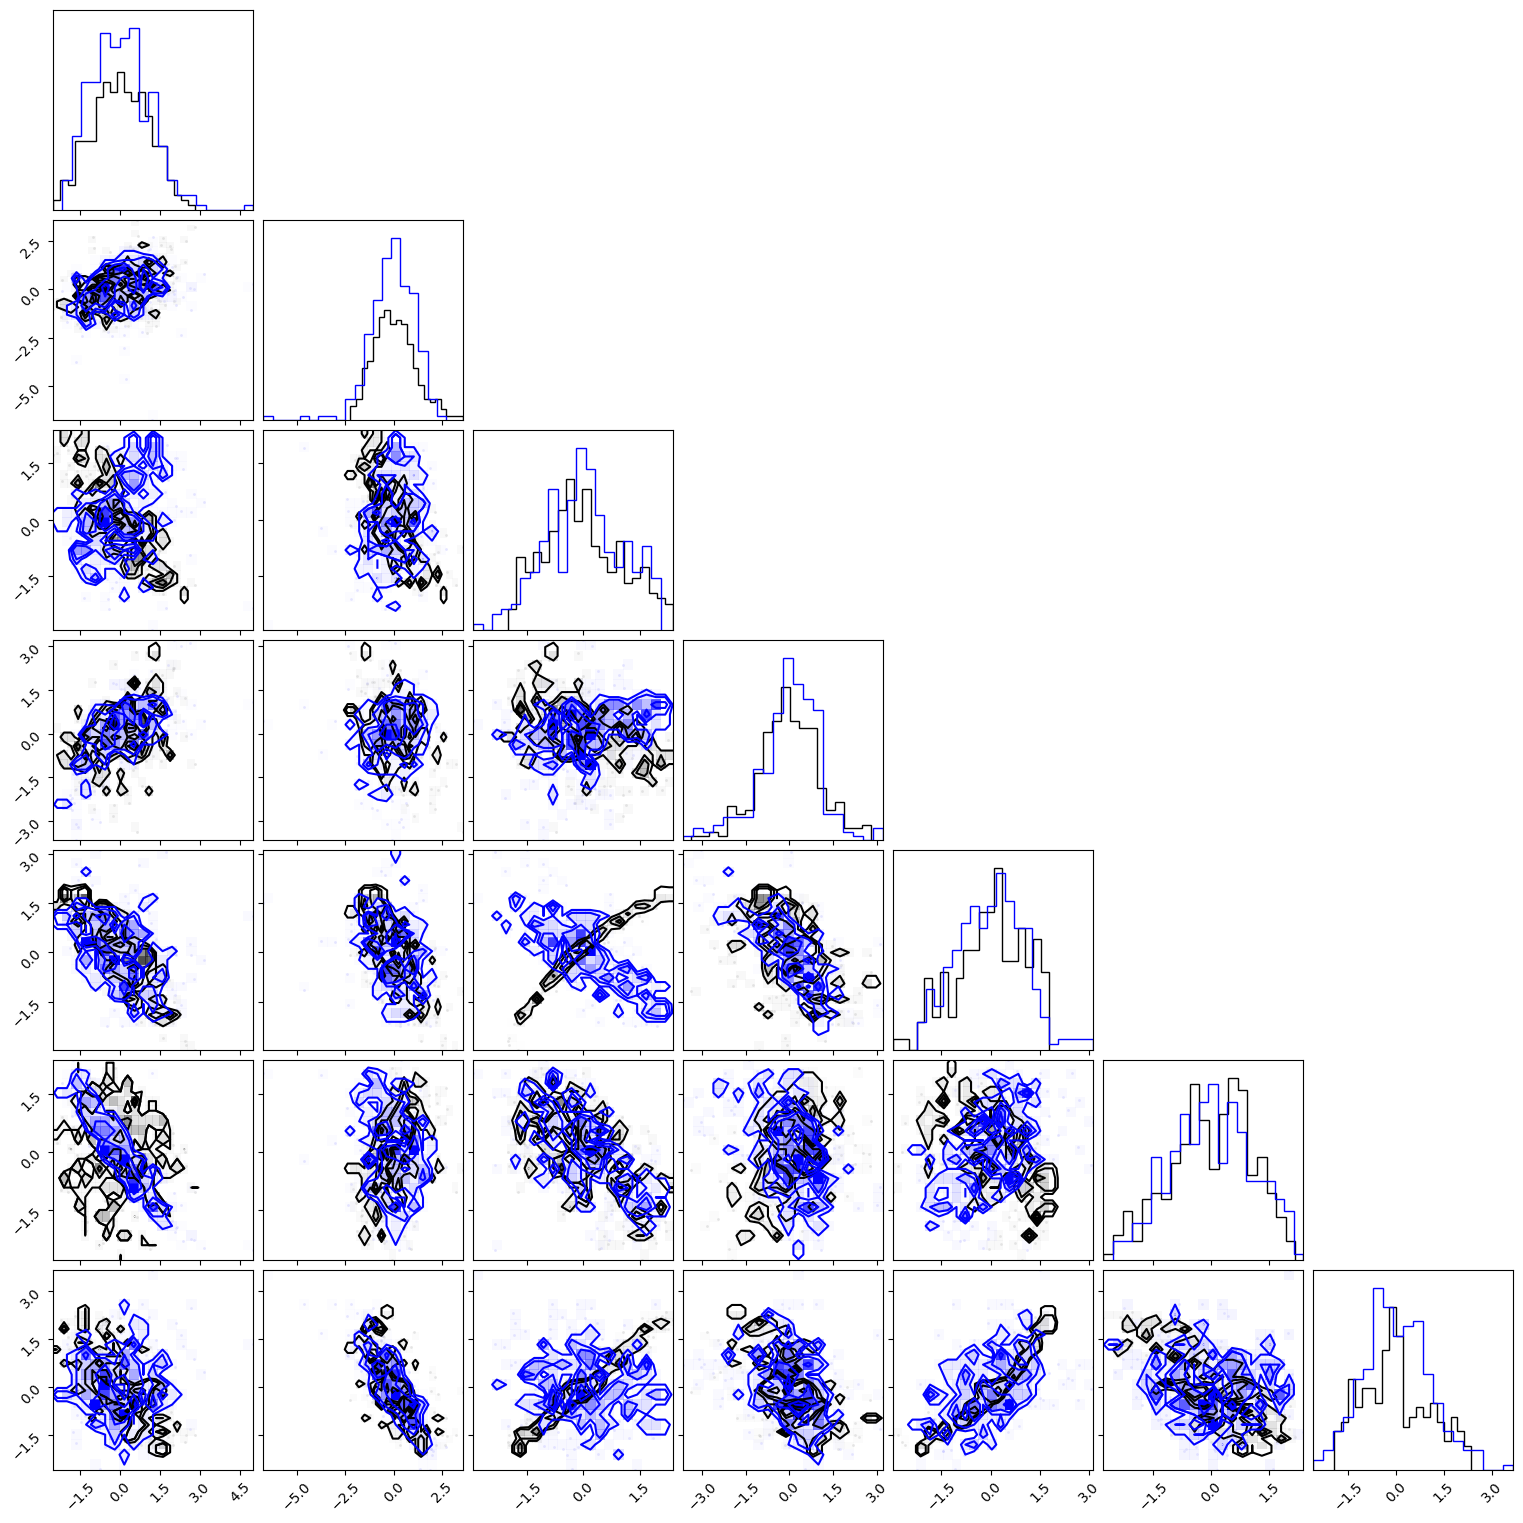

In [194]:
import corner
from sklearn.preprocessing import StandardScaler, MinMaxScaler



fig = corner.corner(other_summs[::10, :7])
corner.corner(StandardScaler().fit_transform(preds_test.numpy())[::10, :7], fig=fig, color='blue')
plt.show()

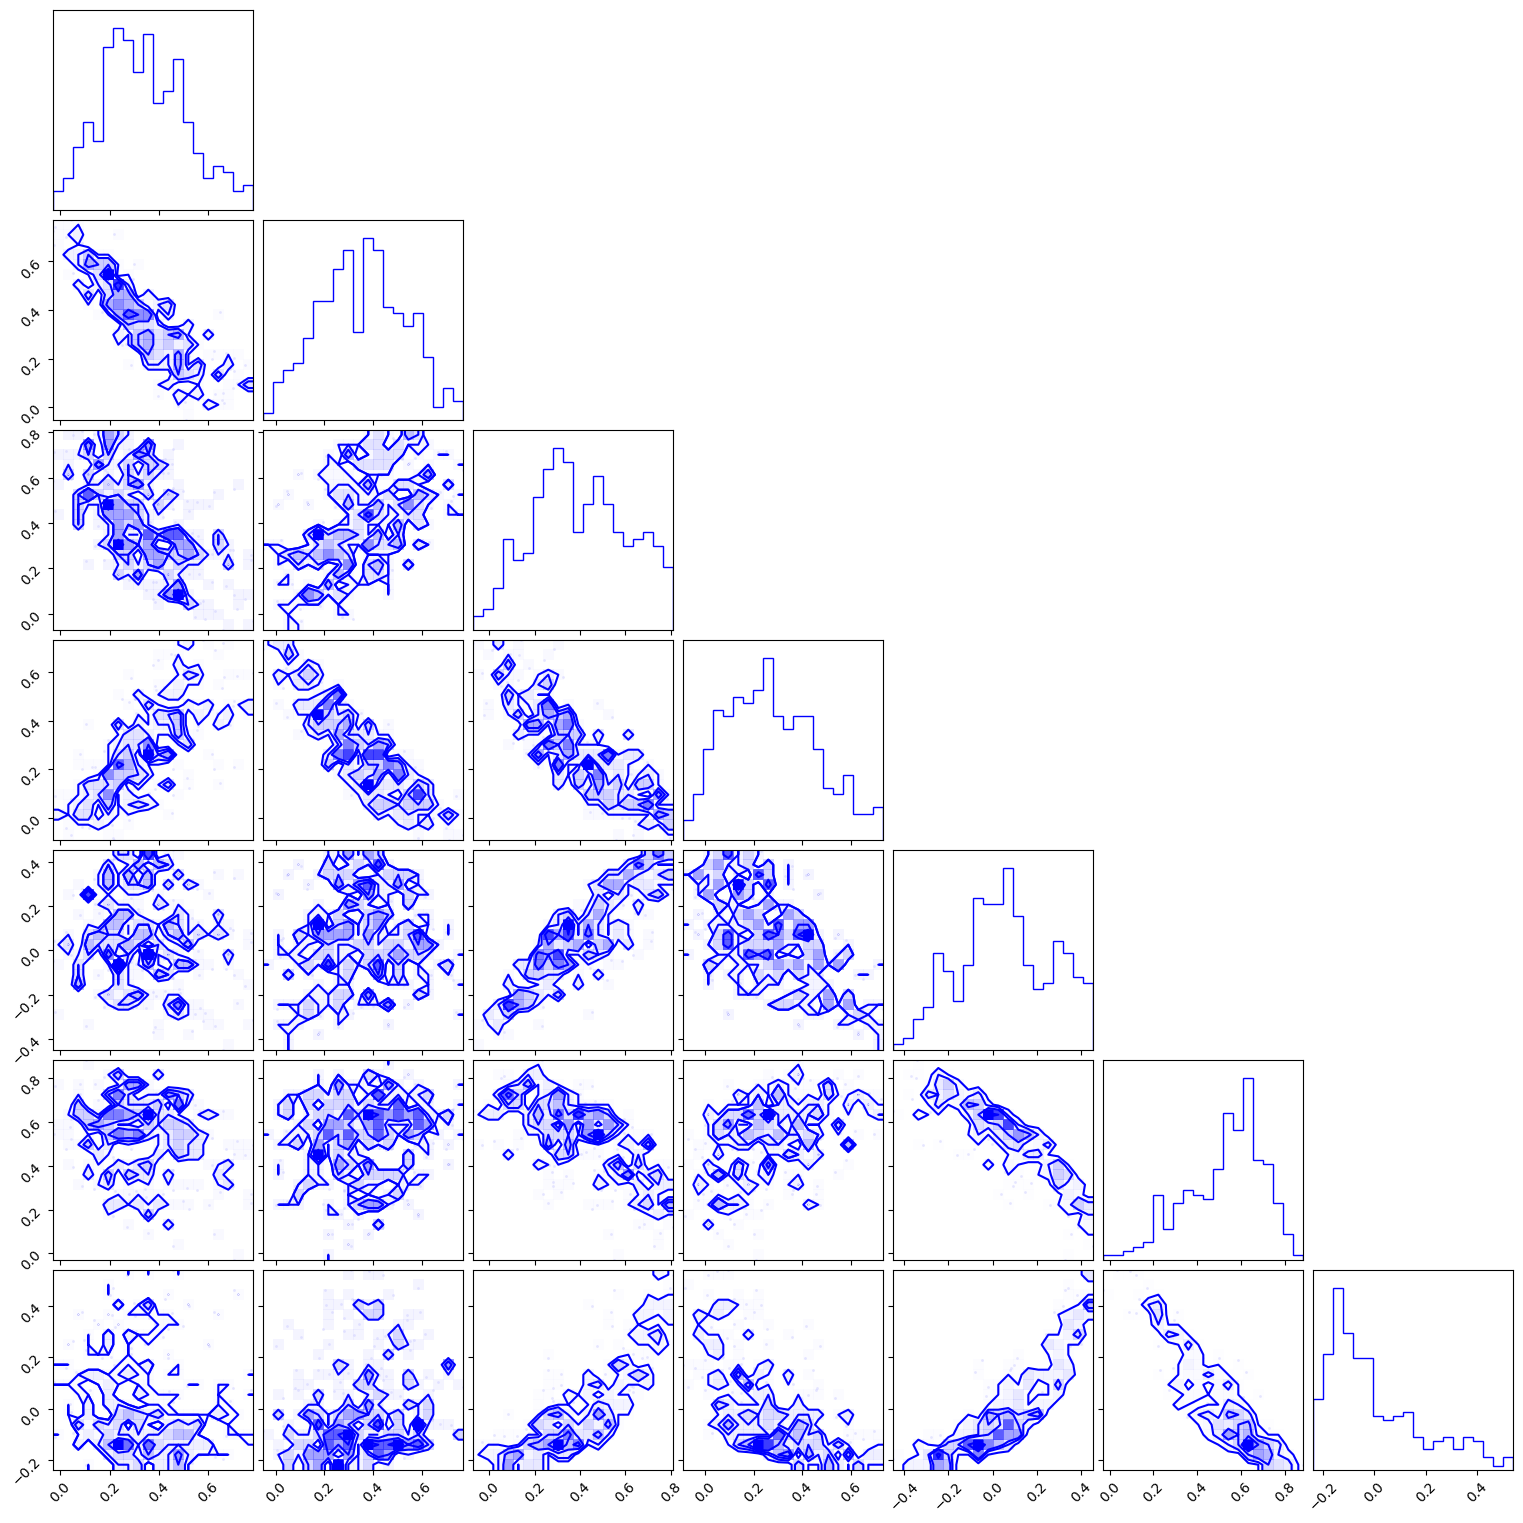

In [106]:
corner.corner(preds_test.numpy()[::10, :7], color='blue')
plt.show()